<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_5/Day_4%20/Daily_challenge/daily_challenge_pokemon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge: Pokemon Win Prediction Analysis
===

**What you will create**

A cleaned Pokemon dataset with engineered features (e.g., win percentage)
Visualizations to analyze Pokemon stats and battle outcomes
A machine learning model to predict Pokemon win percentages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

DATA PREPARATION:

In [2]:
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')

In [3]:
pokemon.loc[pokemon['#'] == 62, 'Name'] = 'Primeape'

#NaN values in Type 2
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

#Win Percentage
total_battles = combats['First_pokemon'].value_counts() + combats['Second_pokemon'].value_counts()

total_wins = combats['Winner'].value_counts()

win_stats = pd.DataFrame({
    'Total_Battles': total_battles,
    'Total_Wins': total_wins
}).fillna(0)

win_stats['Win_Percentage'] = (win_stats['Total_Wins'] / win_stats['Total_Battles']) * 100

pokemon = pokemon.merge(win_stats['Win_Percentage'], left_on='#', right_index=True, how='left')
pokemon['Win_Percentage'] = pokemon['Win_Percentage'].fillna(0)

EXPLORATORY ANALYSIS & VISUALIZATION

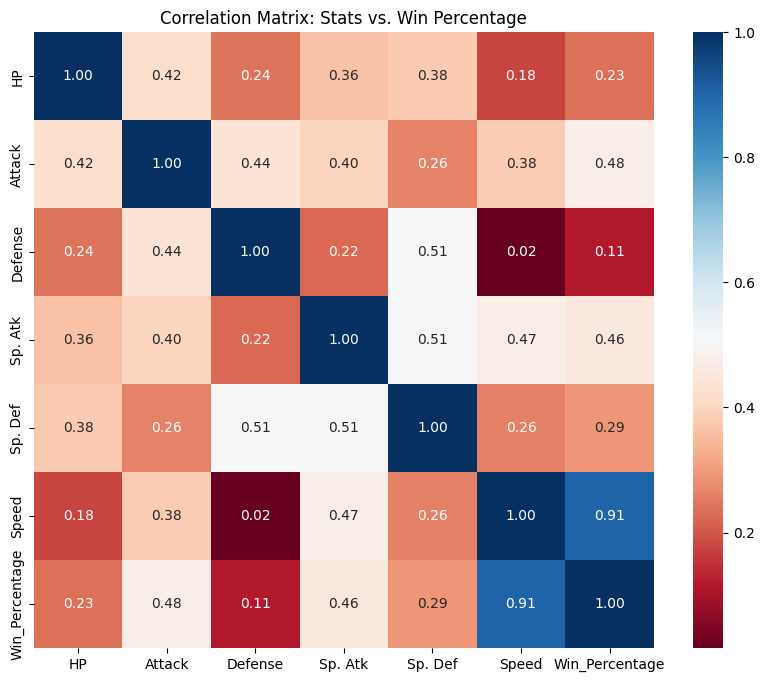

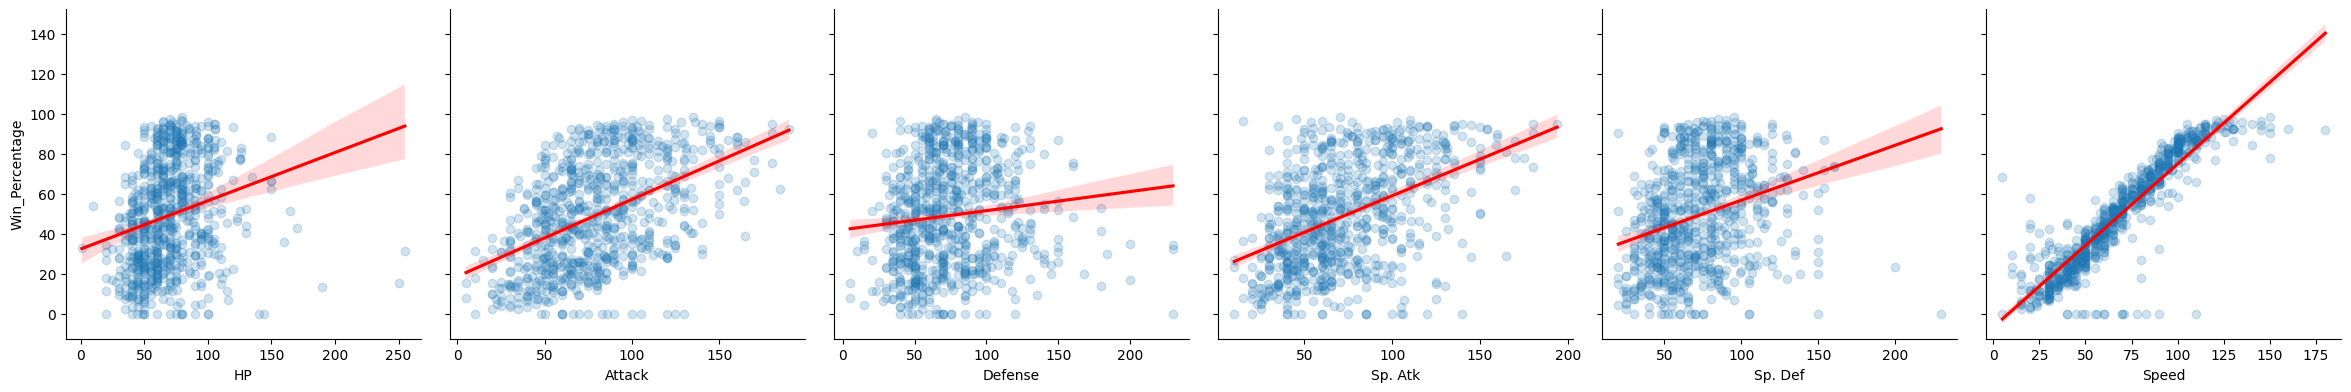

--- Top 10 Pokemon by Win Percentage ---
                         Name  Win_Percentage  Speed
154           Mega Aerodactyl       98.449612    150
512                   Weavile       97.478992    125
703    Tornadus Therian Forme       96.800000    121
19              Mega Beedrill       96.638655    145
153                Aerodactyl       96.453901    130
476              Mega Lopunny       96.124031    135
726                  Greninja       96.062992    122
716  Meloetta Pirouette Forme       95.934959    128
164             Mega Mewtwo Y       95.200000    140
349             Mega Sharpedo       95.000000    105


In [4]:
#Correlation Matrix:
numeric_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']
plt.figure(figsize=(10, 8))
sns.heatmap(pokemon[numeric_cols].corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix: Stats vs. Win Percentage')
plt.show()

#PairGrid for Stats vs Win Percentage:
g = sns.PairGrid(pokemon, y_vars=["Win_Percentage"], x_vars=['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed'], height=4)
g.map(sns.regplot, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.show()

# Top 10 Pokemon by Win Percentage:
print("--- Top 10 Pokemon by Win Percentage ---")
print(pokemon.sort_values(by='Win_Percentage', ascending=False)[['Name', 'Win_Percentage', 'Speed']].head(10))

**The Correlation Matrix** reveals that Speed is the single most influential factor in determining a Pokemon's success, showing a near-perfect positive relationship with win percentage. This suggests that the combat simulation heavily favors "first-strike" mechanics, where faster Pokemon can eliminate opponents before they can retaliate. While Attack and Special Attack also contribute positively to victory, defensive stats like HP and Defense show a significantly weaker correlation. This indicates that being a "tank" is less effective in this specific environment than being a high-speed "glass cannon".

___

**The Scatter Plots** further illustrate this trend, showing a tight, upward slope for Speed compared to the more scattered distributions of other stats. In the HP and Defense plots, we can see many Pokemon with high base stats but very low win percentages, reinforcing the idea that durability cannot compensate for a lack of speed. Our machine learning results support this complexity; the Random Forest model outperformed simple Linear Regression because it could better capture these non-linear "speed thresholds" and interactions between stats to predict outcomes with an average error of only about 5-6%.

MACHINE LEARNING:


In [5]:
#Features (X) and Target (y):
X = pokemon[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']]
X['Legendary'] = X['Legendary'].astype(int) # Convert boolean to 0/1
y = pokemon['Win_Percentage']

#Train/Test Split (80/20):
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Models to evaluate:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

print("\n--- Model Performance ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    print(f"{name}: {mae:.4f}")

#Saving the final cleaned dataset:
pokemon.to_csv('cleaned_pokemon_results.csv', index=False)

/tmp/ipykernel_5626/1049597450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Legendary'] = X['Legendary'].astype(int) # Convert boolean to 0/1



--- Model Performance ---
Linear Regression: 6.3687
Random Forest: 5.7642
Decision Tree: 7.2106


Summary of the findings:
===

The analysis of 50,000 Pokemon battles reveals that Speed is the most critical factor for victory, showing a near-perfect positive correlation with win percentage. This suggests that in this simulation, the ability to strike first is often decisive, overshadowing defensive attributes like HP and Defense, which showed much weaker relationships with success. High-tier performers, such as Mega Aerodactyl and Weavile, consistently reached win rates above 95% primarily due to their superior speed and offensive stats.

When comparing machine learning models, the Random Forest Regressor proved to be the most effective, achieving the lowest Mean Absolute Error (~5.76). This model outperformed Linear Regression because it could better account for non-linear "speed thresholds"—where being slightly faster than an opponent provides a massive statistical advantage. Ultimately, the data indicates that a high-speed "glass cannon" strategy is significantly more effective for winning battles in this dataset than a high-durability "tank" strategy.